In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
columns = ['mcv', 'alkphos', 'sgpt', 'sgot', 'gammagt', 'drinks', 'selector']
df = pd.read_csv('bupa.data', header=None, names=columns)
df = df.drop(columns=['selector'])
print(df.describe())

              mcv     alkphos        sgpt        sgot     gammagt      drinks
count  345.000000  345.000000  345.000000  345.000000  345.000000  345.000000
mean    90.159420   69.869565   30.405797   24.643478   38.284058    3.455072
std      4.448096   18.347670   19.512309   10.064494   39.254616    3.337835
min     65.000000   23.000000    4.000000    5.000000    5.000000    0.000000
25%     87.000000   57.000000   19.000000   19.000000   15.000000    0.500000
50%     90.000000   67.000000   26.000000   23.000000   25.000000    3.000000
75%     93.000000   80.000000   34.000000   27.000000   46.000000    6.000000
max    103.000000  138.000000  155.000000   82.000000  297.000000   20.000000


Welche zwei Merkmale sind ähnlich: sgpt und sgot (ähnliche Mittelwerte und Streuung)
Welche sind unähnlich:  mcv (std=4.4, sehr eng) und gammagt (std=39.3, sehr breit)
Standardisieren: Ja, weil die Skalen sehr unterschiedlich sind

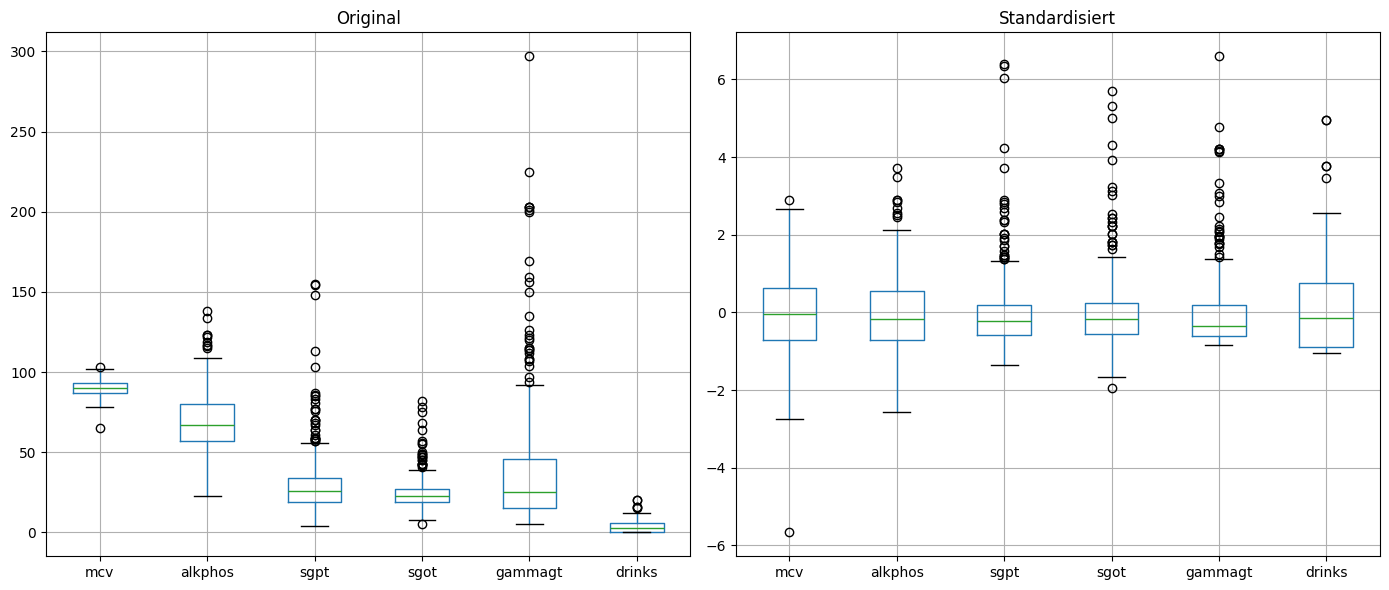

In [3]:


# Standardisierung
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Boxplot vorher vs nachher
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df.boxplot(ax=axes[0])
axes[0].set_title('Original')

df_scaled.boxplot(ax=axes[1])
axes[1].set_title('Standardisiert')

plt.tight_layout()
plt.show()

Nach der Standardisierung liegen alle Merkmale auf einer vergleichbaren Skala (Mittelwert 0, Std 1). Im Original dominiert gammagt mit Werten bis 297 den Plot, nach der Standardisierung sind alle Boxen vergleichbar groß.

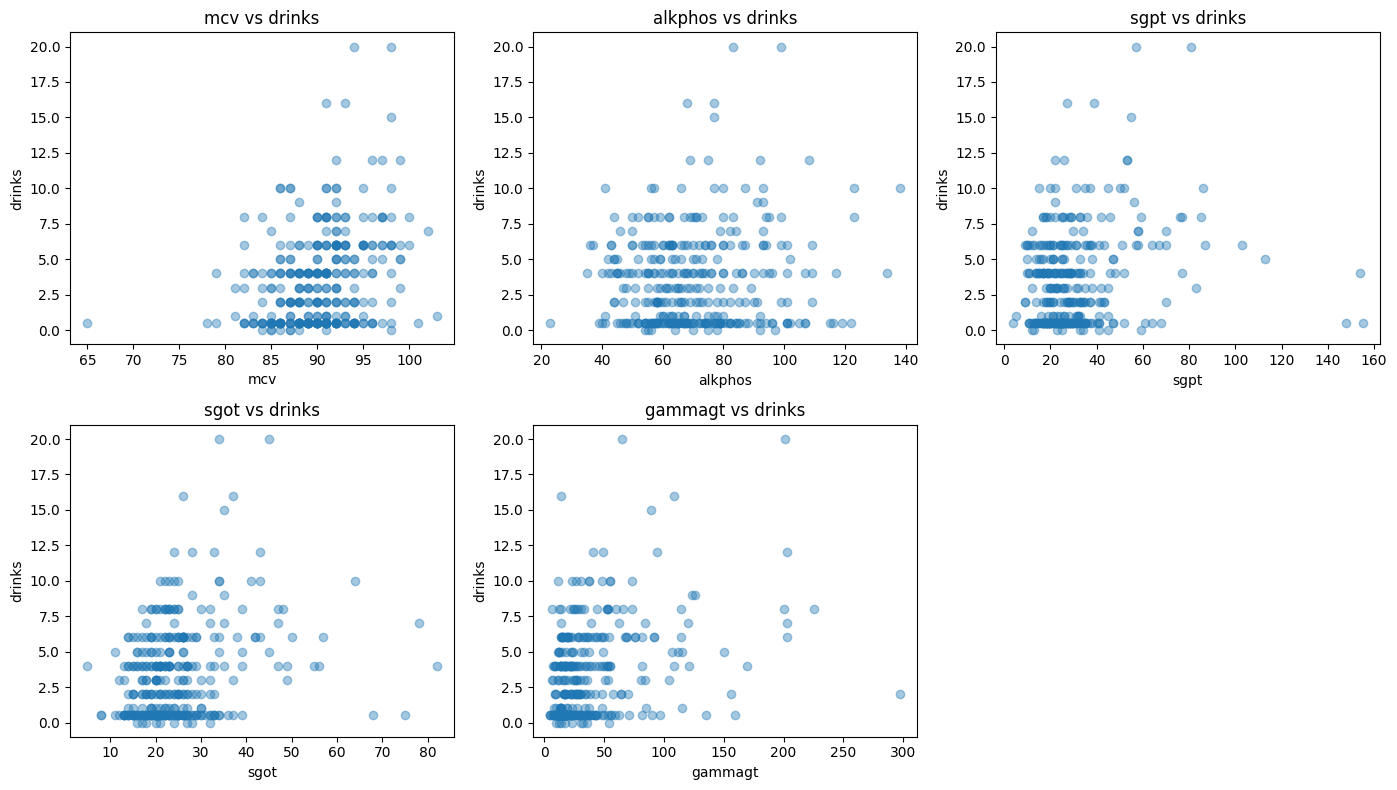

In [4]:
y = df['drinks']
features = df.columns.drop('drinks')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], y, alpha=0.4)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('drinks')
    axes[i].set_title(f'{feature} vs drinks')

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

gammagt hat im Vergleich zu den anderen Features den stärksten linearen Zusammenhang mit drinks, jedoch ist dieser Zusammenhang insgesamt noch schwach.

In [5]:
correlations = df.corr()['drinks'].drop('drinks')
print(correlations)

mcv        0.312680
alkphos    0.100796
sgpt       0.206848
sgot       0.279588
gammagt    0.341224
Name: drinks, dtype: float64


Alle Werte sind positiv (steigen gemeinsam mit drinks) aber alle unter 0.5, also insgesamt schwache Zusammenhänge.

In [6]:

df_scaled = df_scaled

X = df_scaled.drop(columns=['drinks'])
y = df_scaled['drinks']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print("R²:", r2)


R²: 0.188294282158334


Modell kann nur ungefähr 18,8% der Unterschiede von drinks erklären

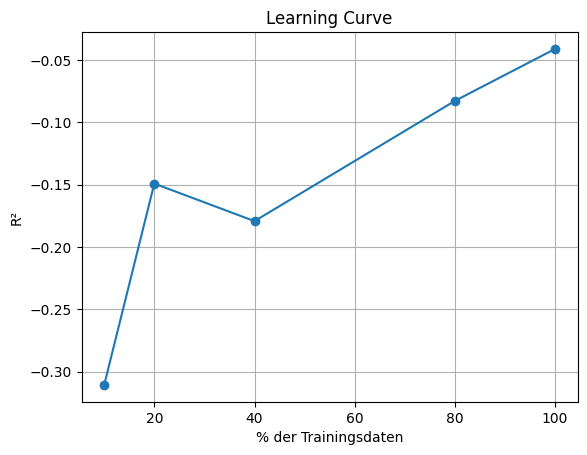

 10% der Daten → R² = -0.3106
 20% der Daten → R² = -0.1492
 40% der Daten → R² = -0.1793
 80% der Daten → R² = -0.0829
100% der Daten → R² = -0.0413


In [7]:
X = df_scaled.drop(columns=['drinks']).values
y = df_scaled['drinks'].values

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

np.random.seed(42)
indices = np.random.permutation(len(X_train_full))

percentages = [0.1, 0.2, 0.4, 0.8, 1.0]
r2_scores = []

for p in percentages:
    n = int(len(X_train_full) * p)
    idx = indices[:n]
    X_sub = X_train_full[idx]
    y_sub = y_train_full[idx]
    
    model = LinearRegression()
    model.fit(X_sub, y_sub)
    r2_scores.append(r2_score(y_test, model.predict(X_test)))

# Plot
plt.plot([10, 20, 40, 80, 100], r2_scores, marker='o')
plt.xlabel('% der Trainingsdaten')
plt.ylabel('R²')
plt.title('Learning Curve')
plt.grid(True)
plt.show()

for p, score in zip([10, 20, 40, 80, 100], r2_scores):
    print(f"{p:>3}% der Daten → R² = {score:.4f}")    


In [8]:
X_train_df = pd.DataFrame(X_train_full, columns=df_scaled.drop(columns=['drinks']).columns)
print(X_train_df.corrwith(pd.Series(y_train_full)))

mcv        0.314998
alkphos    0.100142
sgpt       0.184925
sgot       0.269322
gammagt    0.385736
dtype: float64


Modell mit 100% der Trainingsdaten empfehle ich, da es den höchsten R²-Score auf den Testdaten erzielt. Generell sind alle R²-Werte negativ, was auf schwache lineare Zusammenhänge im Datensatz hindeutet.

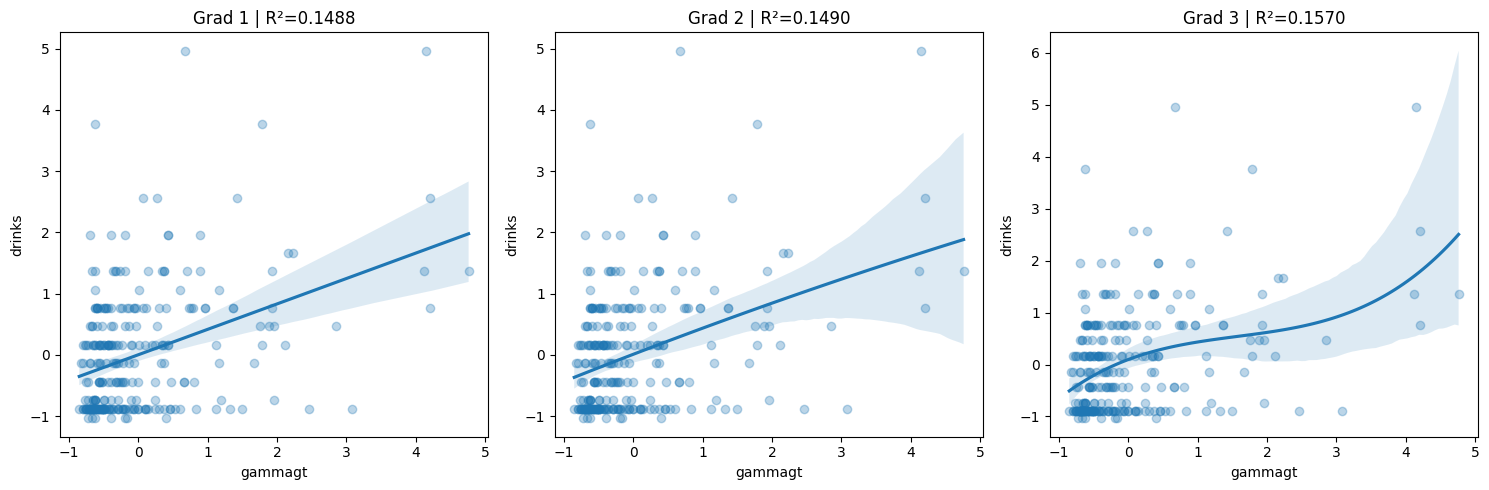

In [9]:
gammagt_train = X_train_df['gammagt'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for degree in [1, 2, 3]:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(gammagt_train.reshape(-1, 1), y_train_full)
    r2 = r2_score(y_train_full, model.predict(gammagt_train.reshape(-1, 1)))
    
    sns.regplot(x=gammagt_train, y=y_train_full, order=degree, 
                ax=axes[degree-1], scatter_kws={'alpha': 0.3})
    axes[degree-1].set_title(f'Grad {degree} | R²={r2:.4f}')
    axes[degree-1].set_xlabel('gammagt')
    axes[degree-1].set_ylabel('drinks')

plt.tight_layout()
plt.show()


Gewählt wurde gammagt da es die höchste Korrelation (0.386) mit drinks auf den Trainingsdaten hat. Alle drei Modelle zeigen mit R²≈0.15 ein Underfitting – die Kurven können die Datenpunkte nicht gut beschreiben. Der Unterschied zwischen Grad 1 und 3 ist minimal, was darauf hindeutet dass eine polynomiale Erweiterung hier kaum hilft. Overfitting ist nicht erkennbar da der R² kaum steigt.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_class = (df['drinks'] > 3).astype(int)

X = df_scaled.drop(columns=['drinks']).astype(float)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X, y_class, test_size=1/3, random_state=42)

model = LogisticRegression(solver='lbfgs')
model.fit(X_train_h, y_train_h)

print("Accuracy Train:", accuracy_score(y_train_h, model.predict(X_train_h)))
print("Accuracy Test:", accuracy_score(y_test_h, model.predict(X_test_h)))

Accuracy Train: 0.6869565217391305
Accuracy Test: 0.6


Accuracy Train: 0.69, Accuracy Test: 0.60. Das Modell ist nicht zufriedenstellend – 60% auf den Testdaten ist nur leicht besser als zufällig raten (50%). Um die Performance zu steigern könnte man: mehr Features hinzufügen, andere Klassengrenzen ausprobieren, oder ein komplexeres Modell wie Random Forest verwenden.